In [1]:
import pandas as pd
from datapaths import Datapaths
import matplotlib.pyplot as plt


In [2]:
dp = Datapaths()

In [3]:
dp.print_paths()

name          | path                                                             | tags       | type | updated at               
--------------+------------------------------------------------------------------+------------+------+--------------------------
dr3_sample_v1 | /home/alex/Data/Work/Sources/gaia_vis/data/dr3_sample_v1.parquet | dr3,sample | data | 2026-03-12T18:47:35+01:00


In [ ]:
COLUMNS = [
    "source_id",
    "ra", "ra_error", "dec", "dec_error", "parallax", "parallax_error", "parallax_over_error", 
    "pm", "pmra", "pmra_error", "pmdec", "pmdec_error", "phot_g_mean_flux", "phot_g_mean_flux_error", 
    "phot_g_mean_flux_over_error", "phot_g_mean_mag", "phot_bp_mean_flux", "phot_bp_mean_flux_error", 
    "phot_bp_mean_flux_over_error", "phot_bp_mean_mag", "phot_rp_mean_flux", "phot_rp_mean_flux_error", 
    "phot_rp_mean_flux_over_error", "phot_rp_mean_mag", "bp_rp", "bp_g", "g_rp", "radial_velocity", 
    "radial_velocity_error", "phot_variable_flag", "l", "b", "ecl_lon", "ecl_lat", "in_qso_candidates", 
    "in_galaxy_candidates", "non_single_star", "teff_gspphot", "teff_gspphot_lower", "teff_gspphot_upper", 
    "logg_gspphot", "logg_gspphot_lower", "logg_gspphot_upper", "mh_gspphot", "mh_gspphot_lower", 
    "mh_gspphot_upper", "distance_gspphot", "distance_gspphot_lower", "distance_gspphot_upper"
]

### Columns explanations
- **"source_id"**: <br>an id that is unique within given DR. Not unique across different DRs, in fact, there is no 'common' ID for the sources between different DRs - you have to use coordinate matching.
- **"ra", "ra_error", "dec", "dec_error":**<br> coordinates and errors in equatorial system
- **"l", "b":** <br> coordinates in galactic coordinate system (Sun is the center, *l* measured from the direction from the Sun to the center of the galaxy, *b* measures the angle above the galactic plane)
- **"ecl_lon", "ecl_lat":** <br> ecliptic coordinates.
- **"parallax", "parallax_error", "parallax_over_error":** <br> kinda self-explanatory. Warning: parallaxes are somewhat reliable only until 1 kpc. Beyond that it's not just 'errors', it's parallaxes getting negative values (and consequently, producing negative distances) due to high astrometric noise. MW radius is at least 40 kpc. Meaning: do not use distances obtained from parallaxes (unless you're interested only in the closest 100 stars).
- **"pm", "pmra", "pmra_error", "pmdec", "pmdec_error":** <br> proper motions with errors and its components along the *ra* and *dec* directions.
- **"phot_g_mean_flux", "phot_g_mean_flux_error", 
    "phot_g_mean_flux_over_error", "phot_g_mean_mag", "phot_bp_mean_flux", "phot_bp_mean_flux_error", 
    "phot_bp_mean_flux_over_error", "phot_bp_mean_mag", "phot_rp_mean_flux", "phot_rp_mean_flux_error", 
    "phot_rp_mean_flux_over_error", "phot_rp_mean_mag":** <br> fluxes, flux errors, flux-to-error ratios, + magnitudes (-log(fluxes)) for the three Gaia filters.
- **"bp_rp", "bp_g", "g_rp":** <br> colors calculated from *magnitudes*. Be careful! (See the image)
- **"radial_velocity", "radial_velocity_error":** <br> velocity of the star along the line of sight, measured with Doppler shift with RV instrument (usually, but not always)
- **"phot_variable_flag", "in_qso_candidates", "in_galaxy_candidates", "non_single_star":** <br> self-explanatory flags. Do not trust them too much though.
- **"teff_gspphot", "teff_gspphot_lower", "teff_gspphot_upper", "logg_gspphot", "logg_gspphot_lower", "logg_gspphot_upper", "mh_gspphot", "mh_gspphot_lower", "mh_gspphot_upper":** <br> effective surface temperature, surface gravity and metallicity, determined from fitting low-resolution Gaia spectrum to a stellar athmosphere model spectra. Gaia spectra are present not for every source, and we don't have perfect stellar athmosphere models, and the quality of the fit depends on many parameters. So yeah, don't trust it too much too). However, it is good variables to try to visualize with different colors/sizes/whatever, and they have lower and upper boundaries, so it's a good early playground for visualizing uncertainties.
- **"distance_gspphot", "distance_gspphot_lower", "distance_gspphot_upper":** <br> distances estimated from the same model spectra fit. Somewhat better than distances from parallaxes (at least they are not negative), but still not perfect. For good ones we'll have to go to Bailer-Jones catalogue. Again, useful to try to visualize lower-upper boundaries as uncertainties.

<div>
<img src="../plots/gaia_bands.png" width="500"/><br>
BP is shorter wavelengths, so higher energies, so <i>bluer</i>. RP is longer wavelengths->lower energies-><i>redder</i>. If we have higher fluxes in BP than in RP, then the star is 'blue' (hotter, probably younger). If the opposite, the object is 'red' (cooler, probably older, or maybe obscured by dust). However! In astronomy, we calculate colors from magnitudes, not fluxes, all the time, and mags are <i>negative log of the flux</i>. Meaning, if we have larger <i>magnitude</i> in BP than in RP, it means it has <i>lower flux</i> in this band. For this reason positive 'BP-RP', which is calculated in magnitudes, means that BP <i>flux</i> is lower than RP flux, and so the object is red, not blue.
Yes, it's a mess. 
</div>

In [5]:

df = pd.read_parquet(dp['dr3_sample_v1'])

In [7]:
df['parallax_distance'] = 1/df['parallax']

In [8]:
df.describe()

,source_id,ra,ra_error,dec,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,...,logg_gspphot,logg_gspphot_lower,logg_gspphot_upper,mh_gspphot,mh_gspphot_lower,mh_gspphot_upper,distance_gspphot,distance_gspphot_lower,distance_gspphot_upper,parallax_distance
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,8133.000000,8133.000000,8133.000000,8133.000000,8133.000000,...,2584.000000,2584.000000,2584.000000,2584.000000,2584.000000,2584.000000,2584.000000,2584.000000,2584.000000,8133.000000
mean,4.365821e+18,229.354416,1.621719,-18.717931,1.318754,0.366745,0.463519,3.606656,6.573378,-2.623058,...,4.501573,4.452726,4.541787,-1.169967,-1.305327,-1.017766,1427.232056,1353.906738,1527.574097,2.041133
std,1.637779e+18,77.475248,4.937379,36.583109,3.686520,1.001425,0.419696,16.013994,5.626678,5.291818,...,0.547238,0.549854,0.542443,0.891899,0.964360,0.818954,1104.077515,1073.532593,1144.346191,130.946025
min,1.223653e+15,0.085006,0.006345,-87.783573,0.007376,-11.552422,0.010007,-7.545676,0.101711,-62.492783,...,0.194900,0.184900,0.207300,-4.119100,-4.142600,-4.073900,79.100197,78.724403,79.252701,-1544.411001
25%,4.038746e+18,186.514061,0.151121,-47.514869,0.140940,0.008305,0.155714,0.021078,3.575898,-4.851588,...,4.389975,4.348475,4.430875,-1.646500,-1.813750,-1.487725,844.397827,784.962891,928.715088,0.229828
50%,4.287266e+18,260.005276,0.365664,-26.133054,0.338633,0.311941,0.340479,1.107028,5.691582,-2.556649,...,4.666350,4.628750,4.697550,-1.154100,-1.299700,-0.983650,1191.282837,1122.440186,1290.557861,1.495484
75%,5.864856e+18,280.476689,0.930256,6.210761,0.826347,0.681680,0.647439,2.654184,7.983346,-0.420062,...,4.808825,4.762725,4.852250,-0.502425,-0.572550,-0.428675,1705.653687,1625.630737,1809.515747,3.265613
max,6.917407e+18,359.725793,89.593567,88.869040,72.602676,12.599344,4.355501,708.418091,134.190125,81.210790,...,5.161000,5.140400,5.183400,0.796900,0.792100,0.799400,18657.789062,18476.783203,18832.111328,11176.504287


### NaN inspection
Pay attention: we rarely have any radial velocities; we miss gspphot more often than not (because for that we need spectra, and spectra are present only for a fraction of objects, usually the brightest ones); and then we miss parallaxes for about 1/5 of the sample (although it's not like they are very useful in general...)

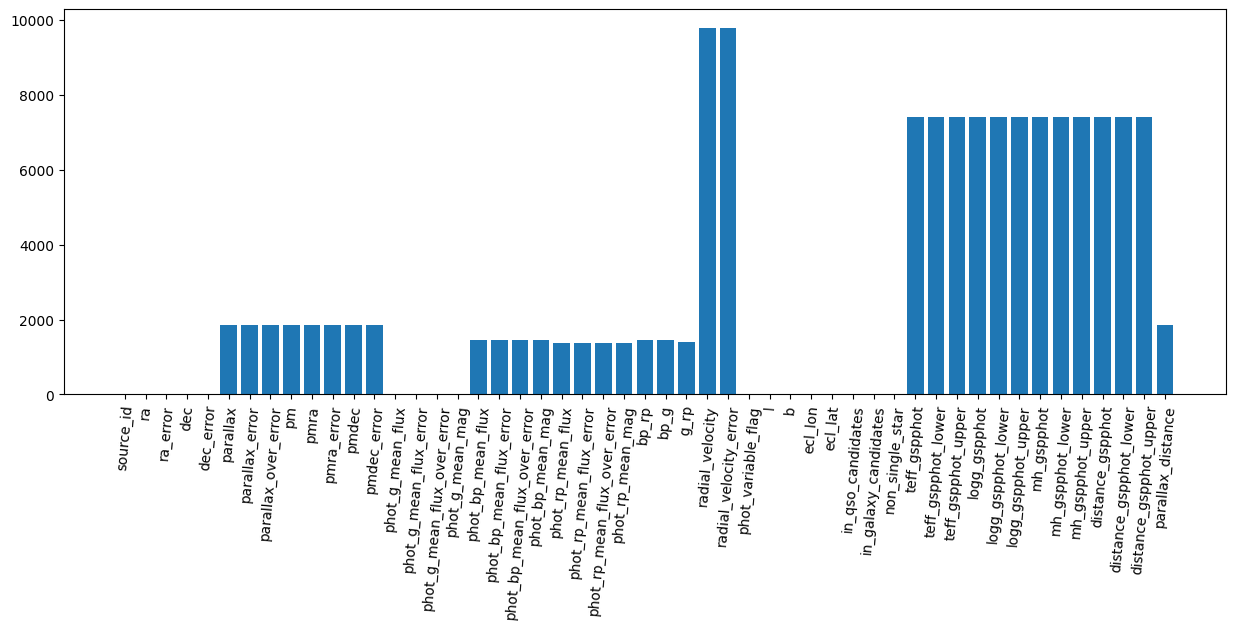

In [21]:
fig,ax = plt.subplots(nrows=1,ncols=1, figsize=(15,5))
ax.bar(range(len(df.columns)),height=df.isna().sum())
ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(list(df.columns));
ax.tick_params(axis='x', rotation=85)

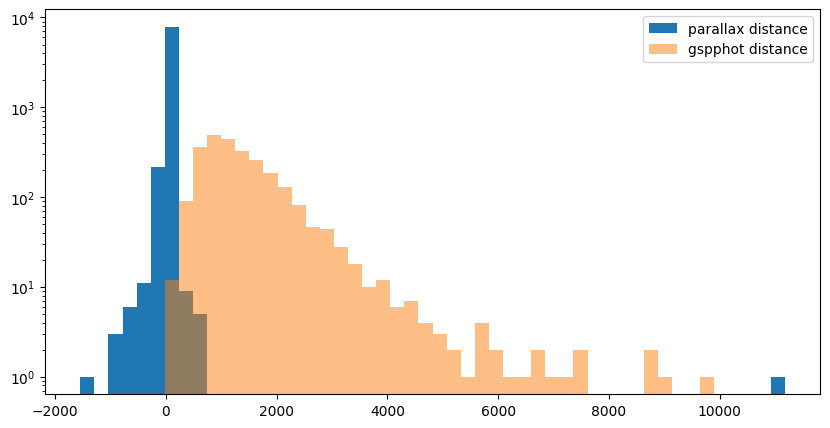

In [22]:
# Just to illustrate negative parallaxes. 
fig, ax = plt.subplots(figsize=(10,5),nrows=1,ncols=1)
bins = ax.hist(df['parallax_distance'],log=True,bins=50,label='parallax distance');
ax.hist(df['distance_gspphot'],log=True,bins=bins[1],alpha=0.5,label='gspphot distance');
ax.legend()